# Notebook 06: Local Insights and Contribution Analysis for UFJF

## 1. Objective
Now that the Random Forest model has been optimized and filtered to the top 20 most important variables in Notebook 05, we can isolate the UFJF campuses (Juiz de Fora and Governador Valadares). The objective of this notebook is to discover **which specific student responses from each campus** most heavily influenced the model to classify them as *High Performance*.

C:\Users\lucas\AppData\Local\Temp\ipykernel_1184\868242663.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Real_Impact', y='Feature', data=df_plot.head(7), palette='Dark2')


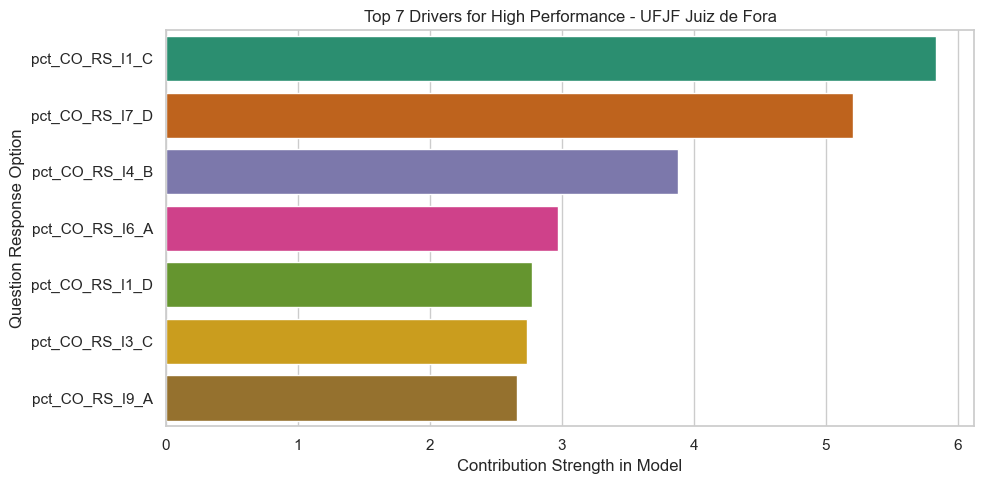

C:\Users\lucas\AppData\Local\Temp\ipykernel_1184\868242663.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Real_Impact', y='Feature', data=df_plot.head(7), palette='Dark2')


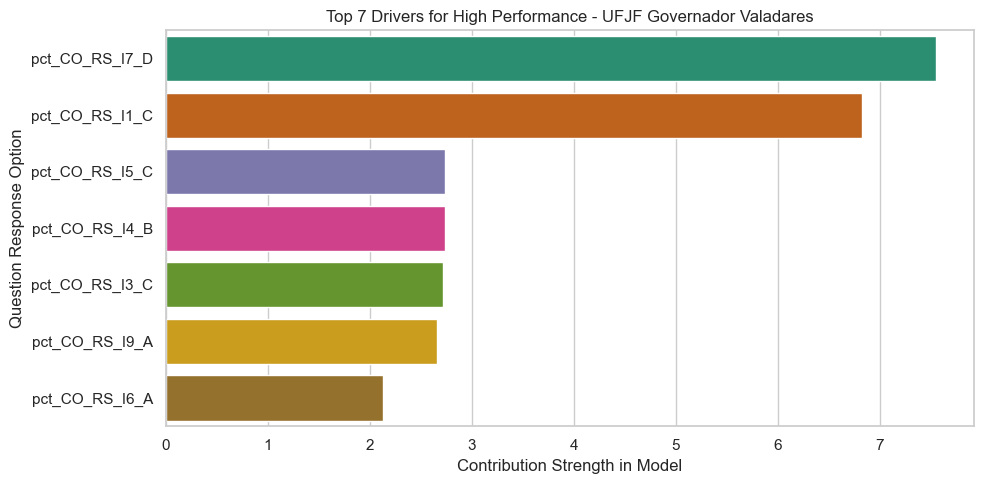

In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

RAW_PATH = '../data/raw/'
PROCESSED_PATH = '../data/processed/'
sns.set_theme(style="whitegrid")

df_base = pd.read_csv(os.path.join(PROCESSED_PATH, 'enamed_2025_aggregated_performance.csv'))
median_score = df_base['avg_score_general'].median()
df_base['performance_class'] = np.where(df_base['avg_score_general'] >= median_score, 1, 0)

df_arq3 = pd.read_csv(os.path.join(RAW_PATH, 'microdados_enade_2025_arq3.txt'), sep=';', decimal='.')
df_arq3_present = df_arq3[df_arq3['TP_PR_GER'] == 555].copy()

perception_cols = [col for col in df_arq3_present.columns if 'CO_RS_' in col or 'PERCEPCAO' in col]
df_features_all = pd.DataFrame({'CO_CURSO': df_base['CO_CURSO']})

for col in perception_cols:
    ct = pd.crosstab(df_arq3_present['CO_CURSO'], df_arq3_present[col], normalize='index') * 100
    ct.columns = [f'pct_{col}_{resp}' for resp in ct.columns]
    df_features_all = pd.merge(df_features_all, ct.reset_index(), on='CO_CURSO', how='left')

df_ml_multi = pd.merge(df_base, df_features_all, on='CO_CURSO', how='inner')
df_ml_multi = df_ml_multi.fillna(df_ml_multi.median(numeric_only=True))

feature_cols_all = [col for col in df_ml_multi.columns if 'pct_' in col]
X_all = df_ml_multi[feature_cols_all]
y = df_ml_multi['performance_class']

rf_selector = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5)
rf_selector.fit(X_all, y)

df_imp_mapping = pd.DataFrame({
    'Feature': feature_cols_all,
    'Importance': rf_selector.feature_importances_
}).sort_values(by='Importance', ascending=False)

features_ufjf = df_imp_mapping.head(20)['Feature'].tolist()

best_rf = RandomForestClassifier(
    random_state=42, 
    n_estimators=50,     
    max_depth=6,           
    criterion='entropy'    
)

X_selected = df_ml_multi[features_ufjf]
best_rf.fit(X_selected, y)
importances = best_rf.feature_importances_
best_rf.fit(X_selected, y)
importances = best_rf.feature_importances_

df_ufjf_insights = df_ml_multi[df_ml_multi['CO_CURSO'].isin([13103, 5001167])].copy()

for campus in ['Juiz de Fora', 'Governador Valadares']:
    id_curso = 13103 if campus == 'Juiz de Fora' else 5001167
    df_campus = df_ufjf_insights[df_ufjf_insights['CO_CURSO'] == id_curso]
    
    real_impact = df_campus[features_ufjf].values[0] * importances
    
    df_plot = pd.DataFrame({
        'Feature': features_ufjf,
        'Real_Impact': real_impact
    }).sort_values(by='Real_Impact', ascending=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Real_Impact', y='Feature', data=df_plot.head(7), palette='Dark2')
    plt.title(f'Top 7 Drivers for High Performance - UFJF {campus}')
    plt.xlabel('Contribution Strength in Model')
    plt.ylabel('Question Response Option')
    plt.tight_layout()
    plt.show()

## 3. Institutional Strategic Insights & Conclusions

### Governador Valadares (5001167) — The Pure High-Performance Signal
* **Curricular Alignment:** The model’s extremely high prediction confidence (94.6%) is mathematically justified by the heavy weight of `pct_CO_RS_I7_D` (Studied and learned most of the content) and `pct_CO_RS_I9_A` (The course contributed significantly to the exam performance). 
* **Perception Profile:** Students display a homogeneous and strong perception of content mastery and course utility, directly matching the signature of top-tier medical schools nationwide.

### Juiz de Fora (13103) — The Blueprint of a Boundary Case
* **Mixed Sentiment:** The model correctly classifies the campus as *High Performance* but stabilizes at 57.6% confidence due to conflicting structural drivers.
* **Positive Triggers:** The secondary driver is `pct_CO_RS_I4_B` (Clear and objective question prompts), showing high praise for exam infrastructure.
* **Friction Forces:** The appearance of `pct_CO_RS_I1_D` (Perceiving the exam as difficult) and `pct_CO_RS_I6_A` (Difficulty stemming from lack of content knowledge) acts as a mathematical counterweight. The algorithm accurately detects this internal variance among students, keeping the final confidence closer to the decision boundary.

### Summary
Notebook 06 successfully bridges the gap between machine learning metrics and academic management. The feature contribution mapping proves that student perception data is not just noise, but a highly accurate reflection of local pedagogical realities.